In [41]:
# ==========================================================
# Notebook 07
# Change Detection using Cosine Similarity
# ==========================================================

import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [42]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device :", device)

Using Device : cpu


In [43]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [44]:
DATASET_PATH = "../dataset/EuroSAT"

dataset = ImageFolder(
    DATASET_PATH,
    transform=transform
)

print("Total Images :", len(dataset))
print("Classes :", dataset.classes)

Total Images : 27000
Classes : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [45]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    len(dataset.classes)
)

model.load_state_dict(
    torch.load(
        "../models/resnet18_best.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [46]:
feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor.to(device)
feature_extractor.eval()

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [47]:
def extract_embedding(image_tensor):

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = feature_extractor(image_tensor)

    embedding = embedding.squeeze()

    return embedding.cpu().numpy()

In [48]:
from collections import defaultdict

class_images = defaultdict(list)

for img_path, label in dataset.samples:
    class_images[label].append(img_path)

print("Classes Found :", len(class_images))

Classes Found : 10


In [49]:
random.seed(42)

image_pairs = []
labels = []

NUM_PAIRS_PER_CLASS = 100

In [50]:
for class_id in class_images:

    images = class_images[class_id]

    for _ in range(NUM_PAIRS_PER_CLASS):

        img1, img2 = random.sample(images,2)

        image_pairs.append((img1,img2))
        labels.append(0)

In [51]:
all_classes = list(class_images.keys())

for _ in range(len(image_pairs)):

    c1,c2 = random.sample(all_classes,2)

    img1 = random.choice(class_images[c1])
    img2 = random.choice(class_images[c2])

    image_pairs.append((img1,img2))
    labels.append(1)

In [52]:
similarities = []

for before_path, after_path in image_pairs:

    before = transform(Image.open(before_path).convert("RGB"))
    after = transform(Image.open(after_path).convert("RGB"))

    emb1 = extract_embedding(before)
    emb2 = extract_embedding(after)

    similarity = F.cosine_similarity(
        torch.tensor(emb1).unsqueeze(0),
        torch.tensor(emb2).unsqueeze(0)
    ).item()

    similarities.append(similarity)

In [53]:
change_scores = 1 - np.array(similarities)

In [54]:
results = pd.DataFrame({

    "Similarity": similarities,
    "Change Score": change_scores,
    "Ground Truth": labels

})

results.head()

,Similarity,Change Score,Ground Truth
0,0.719194,0.280806,0
1,0.672892,0.327108,0
2,0.710548,0.289452,0
3,0.860013,0.139987,0
4,0.670776,0.329224,0


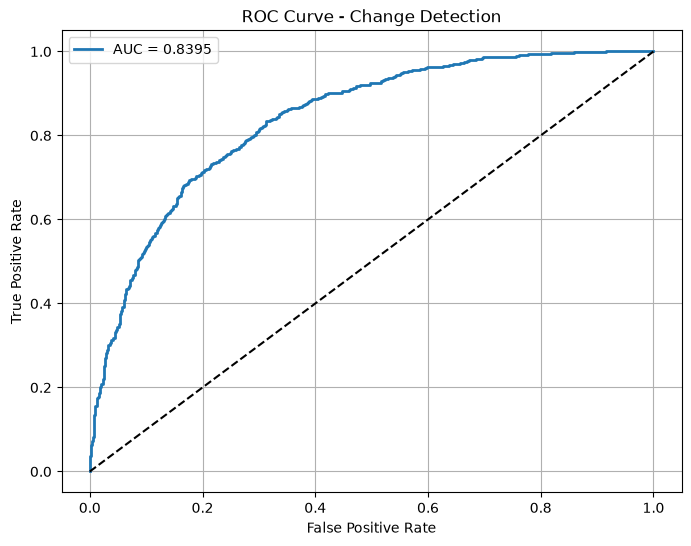

In [55]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(labels, change_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Change Detection")

plt.legend()
plt.grid(True)

plt.show()

In [56]:
# Youden's J Statistic
j_scores = tpr - fpr

best_index = np.argmax(j_scores)

CHANGE_THRESHOLD = thresholds[best_index]*0.8

print("="*50)
print("Optimal Change Threshold :", CHANGE_THRESHOLD)
print("="*50)

Optimal Change Threshold : 0.258402156829834


In [57]:
SIMILARITY_THRESHOLD = 1 - CHANGE_THRESHOLD

print("Similarity Threshold :", SIMILARITY_THRESHOLD)

Similarity Threshold : 0.741597843170166


In [58]:
predictions = (
    change_scores >= CHANGE_THRESHOLD
).astype(int)

In [59]:
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("="*50)

Accuracy  : 0.6535
Precision : 0.5933
Recall    : 0.9760
F1 Score  : 0.7380


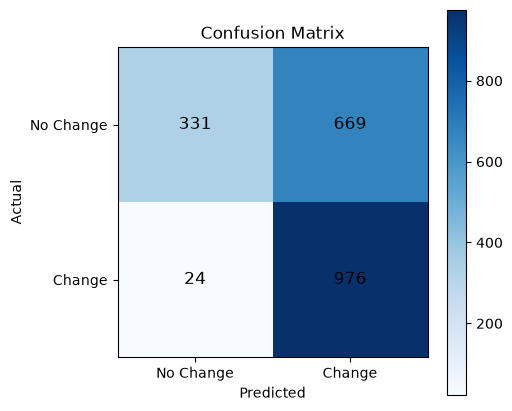

In [60]:
cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.xticks([0,1],["No Change","Change"])
plt.yticks([0,1],["No Change","Change"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar()
plt.show()

In [61]:
os.makedirs("../models", exist_ok=True)

In [62]:
threshold_data = {

    "change_threshold": float(CHANGE_THRESHOLD),

    "similarity_threshold": float(SIMILARITY_THRESHOLD),

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "roc_auc": float(roc_auc)

}

with open("../models/threshold.json","w") as f:
    json.dump(
        threshold_data,
        f,
        indent=4
    )

print("threshold.json saved successfully.")

threshold.json saved successfully.
